Loading negative batches (no-flood)...
Loading positive events (flood)...
Merging into a single unified dataset...
Reordering columns for aesthetic and logical workflow...
Saving FULL dataset (with 3D matrices) to: D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_FULL.pkl
FULL dataset saved successfully!

Creating a lightweight dataset for tabular ML models...
Saving LIGHTWEIGHT dataset to: D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_LIGHTWEIGHT.pkl
LIGHTWEIGHT dataset saved successfully!

Generating Intensity-Duration Plot for Filtered Urban Basins...


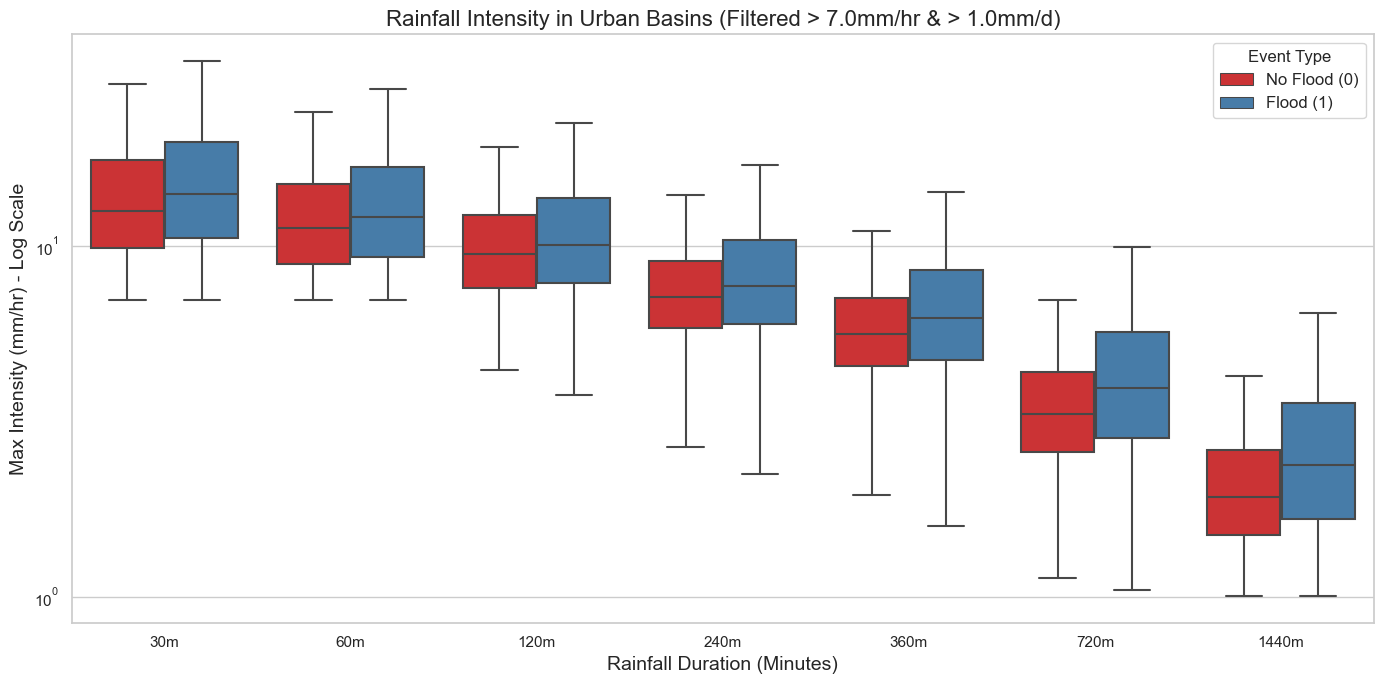

In [4]:
# =================================================================
# 05_chronicle_dataset_preparation_and_eda
# Goal: 
# 1. Load positive (flood) and negative (no-flood) batches.
# 2. Fix Event IDs for traceability.
# 3. Reorder columns logically and aesthetically.
# 4. Save a FULL dataset (with 3D matrices for future CNN models).
# 5. Save a LIGHTWEIGHT dataset (for tabular ML models to prevent RAM issues).
# =================================================================

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION ---
NEGATIVE_BATCHES_DIR = r"D:\Development\RESEARCH\urban_flood_database\chronicle\no_flood_event_outputs"
POSITIVE_EVENTS_PATH = r"\\vscifs\hydrolab1\hydrolab\home\Raz\Research\chronicle\chronicle_rain_master_V07.pkl"

# We now output TWO files: one for Deep Learning (CNN), one for baseline ML (Random Forest)
FULL_OUTPUT_PATH = r"D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_FULL.pkl"
LIGHTWEIGHT_OUTPUT_PATH = r"D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_LIGHTWEIGHT.pkl"

URBAN_THRESHOLD = 20.0 
THRESH_1H = 7.0
THRESH_24H = 1.0

# --- 2. LOAD NEGATIVE BATCHES (CLASS 0) ---
print("Loading negative batches (no-flood)...")
search_pattern = os.path.join(NEGATIVE_BATCHES_DIR, "no_flood_batch_*.pkl")
batch_files = glob.glob(search_pattern)

negative_dfs = []
for file in batch_files:
    temp_df = pd.read_pickle(file)
    negative_dfs.append(temp_df)

negative_df = pd.concat(negative_dfs, ignore_index=True)
negative_df['is_flood'] = 0

# Fix Event IDs
negative_df['start_time'] = pd.to_datetime(negative_df['start_time'])
date_strings = negative_df['start_time'].dt.strftime('%Y%m%d')
negative_df['event_id'] = negative_df['event_id'].astype(str) + '_noflood_' + date_strings

# --- 3. LOAD POSITIVE EVENTS (CLASS 1) ---
print("Loading positive events (flood)...")
positive_df = pd.read_pickle(POSITIVE_EVENTS_PATH)
positive_df['is_flood'] = 1

# --- 4. MERGE DATASETS ---
print("Merging into a single unified dataset...")
common_features = list(set(positive_df.columns) & set(negative_df.columns))
unified_df = pd.concat([positive_df[common_features], negative_df[common_features]], ignore_index=True)

# Free up some memory
del positive_df, negative_df, negative_dfs, temp_df

# --- 5. REORDER COLUMNS LOGICALLY ---
print("Reordering columns for aesthetic and logical workflow...")
logical_order = [
    # Identifiers
    'uuid', 'event_id',
    
    # Time
    'start_time', 'end_time', 'duration_days',
    
    # Basin Geometry and Land Cover
    'area_km2', 'urban_built_up_area_m2', 'urban_percentage',
    
    # Topography and Urban Indices
    'upa_max', 'upa_p95', 'upa_p99', 
    'PFDI_max', 'PFDI_p95', 'PFDI_p99',
    
    # Rainfall Intensities (Sorted temporally)
    '30_max_rainfall_intens', 
    '60_max_rainfall_intens', 
    '120_max_rainfall_intens', 
    '240_max_rainfall_intens', 
    '360_max_rainfall_intens', 
    '720_max_rainfall_intens', 
    '1440_max_rainfall_intens',
    
    # Heavy Data and Metadata (for CNN)
    'imerg_type', 'imerg_meta', 'imerg_mask', 'imerg_matrix', 'geometry_wkt',
    
    # Target Label (Always last)
    'is_flood'
]

# Keep only columns that exist in the dataframe
final_cols = [col for col in logical_order if col in unified_df.columns]

# Append any remaining columns that weren't explicitly listed, just in case
leftover_cols = [col for col in unified_df.columns if col not in final_cols]
final_cols.extend(leftover_cols)

# Apply the new order
unified_df = unified_df[final_cols]

# --- 6. EXPORT FULL DATASET (FOR FUTURE CNN) ---
print(f"Saving FULL dataset (with 3D matrices) to: {FULL_OUTPUT_PATH}")
unified_df.to_pickle(FULL_OUTPUT_PATH)
print("FULL dataset saved successfully!")

# --- 7. EXPORT LIGHTWEIGHT DATASET (FOR BASELINE ML) ---
print("\nCreating a lightweight dataset for tabular ML models...")
heavy_cols = ['imerg_matrix', 'imerg_mask', 'imerg_meta', 'geometry_wkt']

# Drop heavy columns and save
lightweight_df = unified_df.drop(columns=[col for col in heavy_cols if col in unified_df.columns])
lightweight_df.to_pickle(LIGHTWEIGHT_OUTPUT_PATH)

print(f"Saving LIGHTWEIGHT dataset to: {LIGHTWEIGHT_OUTPUT_PATH}")
print("LIGHTWEIGHT dataset saved successfully!")

# --- 8. EXPLORATORY DATA ANALYSIS (EDA) ---
print("\nGenerating Intensity-Duration Plot for Filtered Urban Basins...")
filtered_df = lightweight_df[
    (lightweight_df['urban_percentage'] >= URBAN_THRESHOLD) &
    (lightweight_df['60_max_rainfall_intens'] > THRESH_1H) &
    (lightweight_df['1440_max_rainfall_intens'] > THRESH_24H)
].copy()

intensity_cols = [
    '30_max_rainfall_intens', '60_max_rainfall_intens', 
    '120_max_rainfall_intens', '240_max_rainfall_intens', 
    '360_max_rainfall_intens', '720_max_rainfall_intens', 
    '1440_max_rainfall_intens'
]
intensity_cols = [col for col in intensity_cols if col in filtered_df.columns]

if not filtered_df.empty and intensity_cols:
    melted_df = pd.melt(
        filtered_df, 
        id_vars=['is_flood'], 
        value_vars=intensity_cols,
        var_name='Duration', 
        value_name='Intensity (mm/hr)'
    )
    
    melted_df['Duration'] = melted_df['Duration'].apply(lambda x: x.split('_')[0] + 'm')
    
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    ax = sns.boxplot(
        data=melted_df, x='Duration', y='Intensity (mm/hr)', 
        hue='is_flood', palette="Set1", showfliers=False 
    )
    plt.title(f'Rainfall Intensity in Urban Basins (Filtered > {THRESH_1H}mm/hr & > {THRESH_24H}mm/d)', fontsize=16)
    plt.xlabel('Rainfall Duration (Minutes)', fontsize=14)
    plt.ylabel('Max Intensity (mm/hr) - Log Scale', fontsize=14)
    plt.yscale('log')
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['No Flood (0)', 'Flood (1)'], title='Event Type', fontsize=12)
    plt.tight_layout()
    plt.show()

In [9]:
unified_df

,uuid,event_id,start_time,end_time,duration_days,area_km2,urban_built_up_area_m2,urban_percentage,upa_max,upa_p95,...,240_max_rainfall_intens,360_max_rainfall_intens,720_max_rainfall_intens,1440_max_rainfall_intens,imerg_type,imerg_meta,imerg_mask,imerg_matrix,geometry_wkt,is_flood
0,1422c1c0986549d7a3c7d10a09208098,296,959817600.0,959817600.0,1.0,17.902320,6055133.0,33.823174,7775.601562,37.711626,...,2.598750,1.812500,0.923750,0.793125,final,"{'origin_top_left': (19.288329, -98.923354), '...","[[1, 0]]","[[[0.17999999, 0.0]], [[0.26, 0.0]], [[0.53999...","POLYGON ((-98.923354 19.259108, -98.916374 19....",1
1,43553235080041299c3e48978885c635,297,959817600.0,959817600.0,1.0,29.849550,8815066.0,29.531655,7266.895020,0.360294,...,4.931250,3.557500,1.952917,1.090417,final,"{'origin_top_left': (19.346044, -98.953929), '...","[[1, 0], [0, 0]]","[[[0.17, 0.0], [0.17999999, 0.0]], [[0.2699999...","POLYGON ((-98.953929 19.329468, -98.883774 19....",1
2,6532dc29aaa645239f52ad164489e0aa,298,959817600.0,959817600.0,1.0,1760.002208,6223800.0,0.353625,255259.687500,1.637564,...,2.017083,1.375069,1.137462,0.638125,final,"{'origin_top_left': (28.320151, 95.067367), 's...","[[0, 1, 1, 1, 1, 0], [0, 1, 1, 1, 1, 0], [1, 1...","[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.07, 0.0, ...","POLYGON ((95.067367 28.023449, 95.288819 28.09...",1
3,bd7267cb286448798c31cfab0f6a0f95,299,959817600.0,959817600.0,1.0,11.800292,3757833.0,31.845253,8171.314453,0.613581,...,4.931250,3.557500,1.952917,1.090417,final,"{'origin_top_left': (19.337026, -98.974325), '...","[[1], [0]]","[[[0.17], [0.17999999]], [[0.26999998], [0.26]...","POLYGON ((-98.97432499999999 19.337026, -98.93...",1
4,d2205ca5dd1c42f2b6ca67ab9bf1e9e8,300,959817600.0,959817600.0,1.0,105.652324,28337179.0,26.821160,10537.763672,0.304269,...,1.931250,1.287500,0.643750,0.325469,final,"{'origin_top_left': (43.668714, 1.3503293), 's...","[[1, 1, 0], [1, 1, 0]]","[[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], [[0.0, 0....","POLYGON ((1.3503293 43.604335, 1.4399303 43.66...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852379,3e073196-1954-4a99-8a20-f85b98c5c84a,303477_noflood_20230222,2023-02-22 11:30:00,2023-02-26 11:30:00,4.0,37.581221,5972900.0,15.893310,3271.751221,21.196559,...,6.657500,4.996667,2.650833,1.570833,final_no_flood,"{'origin_top_left': (-7.588813, 110.7838), 'sc...","[[1, 0], [0, 0]]","[[[1.38, 2.98], [1.31, 0.90999997]], [[0.79999...","POLYGON ((110.7838 -7.588813, 110.83997 -7.590...",0
852380,8ca393f9-18a7-432d-90fa-82395bdc0298,303477_noflood_20230207,2023-02-07 13:00:00,2023-02-11 13:00:00,4.0,37.581221,5972900.0,15.893310,3271.751221,21.196559,...,6.536250,5.042500,2.805833,1.532500,final_no_flood,"{'origin_top_left': (-7.588813, 110.7838), 'sc...","[[1, 0], [0, 0]]","[[[2.3899999, 2.45], [2.57, 2.3899999]], [[1.5...","POLYGON ((110.7838 -7.588813, 110.83997 -7.590...",0
852381,6e840d20-905e-4ba4-86e2-f9978d859e10,303477_noflood_20230213,2023-02-13 12:00:00,2023-02-17 12:00:00,4.0,37.581221,5972900.0,15.893310,3271.751221,21.196559,...,5.992500,5.184167,3.140417,1.591042,final_no_flood,"{'origin_top_left': (-7.588813, 110.7838), 'sc...","[[1, 0], [0, 0]]","[[[0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, ...","POLYGON ((110.7838 -7.588813, 110.83997 -7.590...",0
852382,74aaeffd-bd07-44d1-a48f-3e8e481ebf8f,303477_noflood_20230501,2023-05-01 11:30:00,2023-05-05 11:30:00,4.0,37.581221,5972900.0,15.893310,3271.751221,21.196559,...,5.015000,3.540000,2.694167,1.575208,final_no_flood,"{'origin_top_left': (-7.588813, 110.7838), 'sc...","[[1, 0], [0, 0]]","[[[0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, ...","POLYGON ((110.7838 -7.588813, 110.83997 -7.590...",0


In [3]:
lightweight_df.columns

Index(['duration_days', '360_max_rainfall_intens', '60_max_rainfall_intens',
       'urban_built_up_area_m2', 'uuid', '720_max_rainfall_intens',
       'start_time', '120_max_rainfall_intens', 'upa_max', 'event_id',
       'area_km2', 'imerg_type', 'upa_p99', 'PFDI_p99', 'upa_p95', 'PFDI_max',
       '30_max_rainfall_intens', 'PFDI_p95', '240_max_rainfall_intens',
       '1440_max_rainfall_intens', 'urban_percentage', 'end_time', 'is_flood'],
      dtype='object')

Loading negative samples (no-flood events)...
Total negative samples loaded: 7402
Loading positive samples (flood events)...
Total positive samples loaded: 404999
Merging positive and negative samples...
Unified dataset shape: (412401, 27)
Columns ordered successfully. Target label 'is_flood' is set as the last column.

Generating basic analysis plots for the unified dataset...


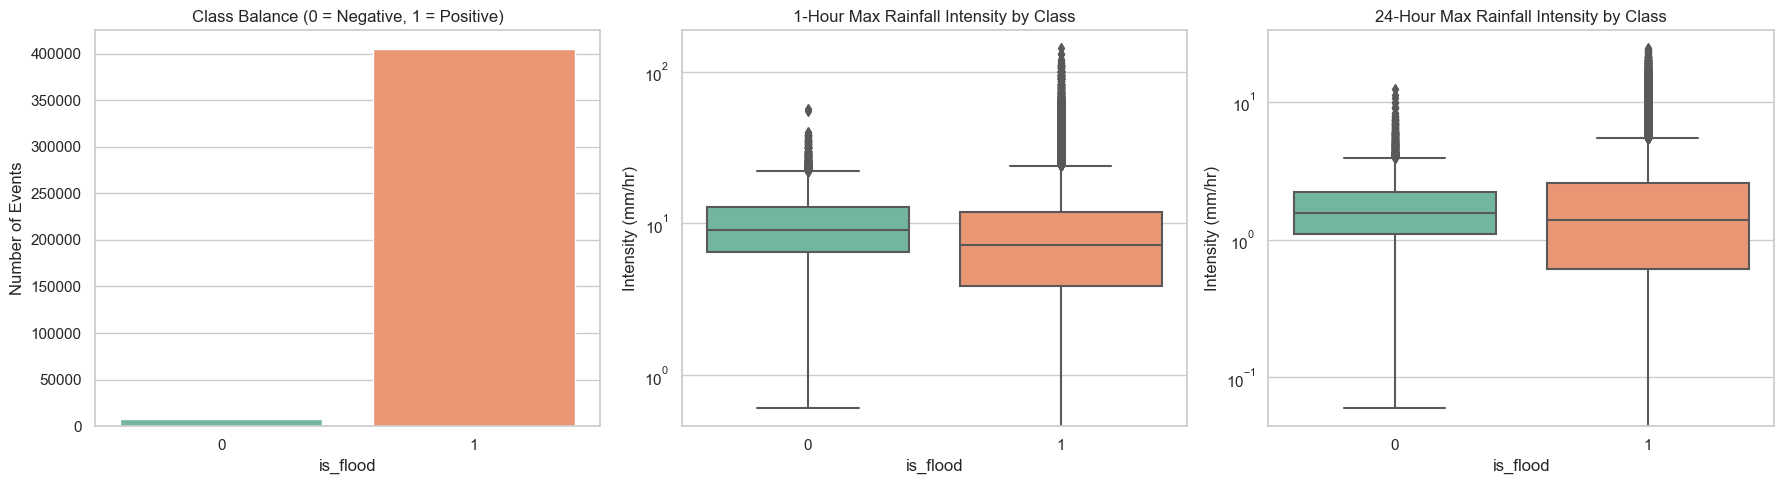


--- Basic Statistics by Class ---
          60_max_rainfall_intens  1440_max_rainfall_intens  PFDI_max  \
is_flood                                                               
0                          10.22                      1.80    420.12   
1                           8.87                      1.91    987.80   

          duration_days  
is_flood                 
0                  4.00  
1                  1.69  

Unified ML dataset saved to: D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_V01.pkl


In [9]:
# =================================================================
# 05_chronicle_dataset_preparation_and_eda
# Goal: 
# 1. Combine positive (flood) and negative (no-flood) samples.
# 2. Generate traceable and unique event IDs for negative samples.
# 3. Reorder columns logically (grouping features, label at the end).
# 4. Perform exploratory data analysis on the unified dataset.
# 5. Export the final balanced dataset for Machine Learning modeling.
# =================================================================

# Standard library imports
import glob
import os

# Third-party library imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. CONFIGURATION ---
NEGATIVE_BATCHES_DIR = r"D:\Development\RESEARCH\urban_flood_database\chronicle\no_flood_event_outputs"
POSITIVE_EVENTS_PATH = r"\\vscifs\hydrolab1\hydrolab\home\Raz\Research\chronicle\chronicle_rain_master_V07.pkl"
UNIFIED_ML_DATASET_PATH = r"D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_V01.pkl"

# Define the logical order of columns (Features followed by the Label)
LOGICAL_COLUMN_ORDER = [
    # Identifiers and Time
    'uuid', 'event_id', 'start_time', 'end_time', 'duration_days',
    
    # Basin Geometry and Land Cover Features
    'area_km2', 'geometry_wkt', 'urban_built_up_area_m2', 'urban_percentage',
    
    # Computed Indices Features (Urban and Topography)
    'upa_max', 'upa_p95', 'upa_p99', 
    'PFDI_max', 'PFDI_p95', 'PFDI_p99',
    
    # Raw IMERG Data and Metadata
    'imerg_type', 'imerg_meta', 'imerg_mask', 'imerg_matrix',
    
    # Calculated Rainfall Intensity Features (Sorted temporally)
    '30_max_rainfall_intens', 
    '60_max_rainfall_intens', 
    '120_max_rainfall_intens', 
    '240_max_rainfall_intens', 
    '360_max_rainfall_intens', 
    '720_max_rainfall_intens', 
    '1440_max_rainfall_intens',
    
    # Target Label (Must be last)
    'is_flood'
]

# --- 2. LOAD AND COMBINE NEGATIVE SAMPLES (CLASS 0) ---
print("Loading negative samples (no-flood events)...")
search_pattern = os.path.join(NEGATIVE_BATCHES_DIR, "no_flood_batch_*.pkl")
batch_files = glob.glob(search_pattern)

negative_samples_list = []
for file_path in batch_files:
    try:
        df = pd.read_pickle(file_path)
        negative_samples_list.append(df)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

if negative_samples_list:
    negative_samples_df = pd.concat(negative_samples_list, ignore_index=True)
    print(f"Total negative samples loaded: {len(negative_samples_df)}")
else:
    raise ValueError("No batch files found. Check the directory path.")

# Fix Event IDs: Make them traceable by appending 'noflood' and the storm's date
negative_samples_df['start_time'] = pd.to_datetime(negative_samples_df['start_time'])
date_strings = negative_samples_df['start_time'].dt.strftime('%Y%m%d')
negative_samples_df['event_id'] = negative_samples_df['event_id'].astype(str) + '_noflood_' + date_strings

# Assign the negative label
negative_samples_df['is_flood'] = 0

# --- 3. LOAD POSITIVE SAMPLES (CLASS 1) ---
print("Loading positive samples (flood events)...")
positive_samples_df = pd.read_pickle(POSITIVE_EVENTS_PATH)

# Assign the positive label
positive_samples_df['is_flood'] = 1
print(f"Total positive samples loaded: {len(positive_samples_df)}")

# --- 4. MERGE AND REORDER DATASET ---
print("Merging positive and negative samples...")
# Keep only common feature columns to avoid structural mismatches
common_features = list(set(positive_samples_df.columns) & set(negative_samples_df.columns))
unified_ml_dataset = pd.concat([positive_samples_df[common_features], negative_samples_df[common_features]], ignore_index=True)

# Reorder columns according to the predefined logical list
final_columns = [col for col in LOGICAL_COLUMN_ORDER if col in unified_ml_dataset.columns]
unified_ml_dataset = unified_ml_dataset[final_columns]

print(f"Unified dataset shape: {unified_ml_dataset.shape}")
print("Columns ordered successfully. Target label 'is_flood' is set as the last column.")

# --- 5. EXPLORATORY DATA ANALYSIS (EDA) ---
print("\nGenerating basic analysis plots for the unified dataset...")
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Class Balance
sns.countplot(data=unified_ml_dataset, x='is_flood', ax=axes[0], palette="Set2")
axes[0].set_title('Class Balance (0 = Negative, 1 = Positive)')
axes[0].set_ylabel('Number of Events')

# Plot B: 1-Hour Rainfall Intensity Distribution
sns.boxplot(data=unified_ml_dataset, x='is_flood', y='60_max_rainfall_intens', ax=axes[1], palette="Set2")
axes[1].set_title('1-Hour Max Rainfall Intensity by Class')
axes[1].set_ylabel('Intensity (mm/hr)')
axes[1].set_yscale('log') 

# Plot C: 24-Hour Rainfall Intensity Distribution
sns.boxplot(data=unified_ml_dataset, x='is_flood', y='1440_max_rainfall_intens', ax=axes[2], palette="Set2")
axes[2].set_title('24-Hour Max Rainfall Intensity by Class')
axes[2].set_ylabel('Intensity (mm/hr)')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

# Print basic statistics
print("\n--- Basic Statistics by Class ---")
stats_cols = ['60_max_rainfall_intens', '1440_max_rainfall_intens', 'PFDI_max', 'duration_days']
existing_stats_cols = [col for col in stats_cols if col in unified_ml_dataset.columns]
print(unified_ml_dataset.groupby('is_flood')[existing_stats_cols].mean().round(2))

# --- 6. SAVE UNIFIED DATASET ---
unified_ml_dataset.to_pickle(UNIFIED_ML_DATASET_PATH)
print(f"\nUnified ML dataset saved to: {UNIFIED_ML_DATASET_PATH}")

In [10]:
unified_ml_dataset

,uuid,event_id,start_time,end_time,duration_days,area_km2,geometry_wkt,urban_built_up_area_m2,urban_percentage,upa_max,...,imerg_mask,imerg_matrix,30_max_rainfall_intens,60_max_rainfall_intens,120_max_rainfall_intens,240_max_rainfall_intens,360_max_rainfall_intens,720_max_rainfall_intens,1440_max_rainfall_intens,is_flood
0,1422c1c0986549d7a3c7d10a09208098,296,959817600.0,959817600.0,1.0,17.902320,"POLYGON ((-98.923354 19.259108, -98.916374 19....",6055133.0,33.823174,7775.601562,...,"[[1, 0]]","[[[0.17999999, 0.0]], [[0.26, 0.0]], [[0.53999...",3.940000,3.60500,3.602500,2.598750,1.812500,0.923750,0.793125,1
1,43553235080041299c3e48978885c635,297,959817600.0,959817600.0,1.0,29.849550,"POLYGON ((-98.953929 19.329468, -98.883774 19....",8815066.0,29.531655,7266.895020,...,"[[1, 0], [0, 0]]","[[[0.17, 0.0], [0.17999999, 0.0]], [[0.2699999...",6.520000,6.49500,6.145000,4.931250,3.557500,1.952917,1.090417,1
2,6532dc29aaa645239f52ad164489e0aa,298,959817600.0,959817600.0,1.0,1760.002208,"POLYGON ((95.067367 28.023449, 95.288819 28.09...",6223800.0,0.353625,255259.687500,...,"[[0, 1, 1, 1, 1, 0], [0, 1, 1, 1, 1, 0], [1, 1...","[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.07, 0.0, ...",5.135833,3.40000,3.329792,2.017083,1.375069,1.137462,0.638125,1
3,bd7267cb286448798c31cfab0f6a0f95,299,959817600.0,959817600.0,1.0,11.800292,"POLYGON ((-98.97432499999999 19.337026, -98.93...",3757833.0,31.845253,8171.314453,...,"[[1], [0]]","[[[0.17], [0.17999999]], [[0.26999998], [0.26]...",6.520000,6.49500,6.145000,4.931250,3.557500,1.952917,1.090417,1
4,d2205ca5dd1c42f2b6ca67ab9bf1e9e8,300,959817600.0,959817600.0,1.0,105.652324,"POLYGON ((1.3503293 43.604335, 1.4399303 43.66...",28337179.0,26.821160,10537.763672,...,"[[1, 1, 0], [1, 1, 0]]","[[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], [[0.0, 0....",5.850000,5.45125,3.862500,1.931250,1.287500,0.643750,0.325469,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412396,3e073196-1954-4a99-8a20-f85b98c5c84a,303477_noflood_20230222,2023-02-22 11:30:00,2023-02-26 11:30:00,4.0,37.581221,"POLYGON ((110.7838 -7.588813, 110.83997 -7.590...",5972900.0,15.893310,3271.751221,...,"[[1, 0], [0, 0]]","[[[1.38, 2.98], [1.31, 0.90999997]], [[0.79999...",14.250000,11.78000,8.372500,6.657500,4.996667,2.650833,1.570833,0
412397,8ca393f9-18a7-432d-90fa-82395bdc0298,303477_noflood_20230207,2023-02-07 13:00:00,2023-02-11 13:00:00,4.0,37.581221,"POLYGON ((110.7838 -7.588813, 110.83997 -7.590...",5972900.0,15.893310,3271.751221,...,"[[1, 0], [0, 0]]","[[[2.3899999, 2.45], [2.57, 2.3899999]], [[1.5...",8.420000,8.42000,7.982500,6.536250,5.042500,2.805833,1.532500,0
412398,6e840d20-905e-4ba4-86e2-f9978d859e10,303477_noflood_20230213,2023-02-13 12:00:00,2023-02-17 12:00:00,4.0,37.581221,"POLYGON ((110.7838 -7.588813, 110.83997 -7.590...",5972900.0,15.893310,3271.751221,...,"[[1, 0], [0, 0]]","[[[0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, ...",8.650000,8.59000,7.812500,5.992500,5.184167,3.140417,1.591042,0
412399,74aaeffd-bd07-44d1-a48f-3e8e481ebf8f,303477_noflood_20230501,2023-05-01 11:30:00,2023-05-05 11:30:00,4.0,37.581221,"POLYGON ((110.7838 -7.588813, 110.83997 -7.590...",5972900.0,15.893310,3271.751221,...,"[[1, 0], [0, 0]]","[[[0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, ...",8.590000,7.75500,6.047500,5.015000,3.540000,2.694167,1.575208,0


Total events in dataset: 412401
Total events after filtering (>= 40.0% urban): 15090

--- Event Counts (Urban Basins Only) ---
No Flood (Class 0): 1179
Flood (Class 1):    13911

--- Mean Values by Class (Urban >= 40.0%) ---
          60_max_rainfall_intens  1440_max_rainfall_intens  PFDI_max  upa_max
is_flood                                                                     
0                          12.84                      2.35   1253.19   309.84
1                           9.72                      1.90    522.81  5486.33


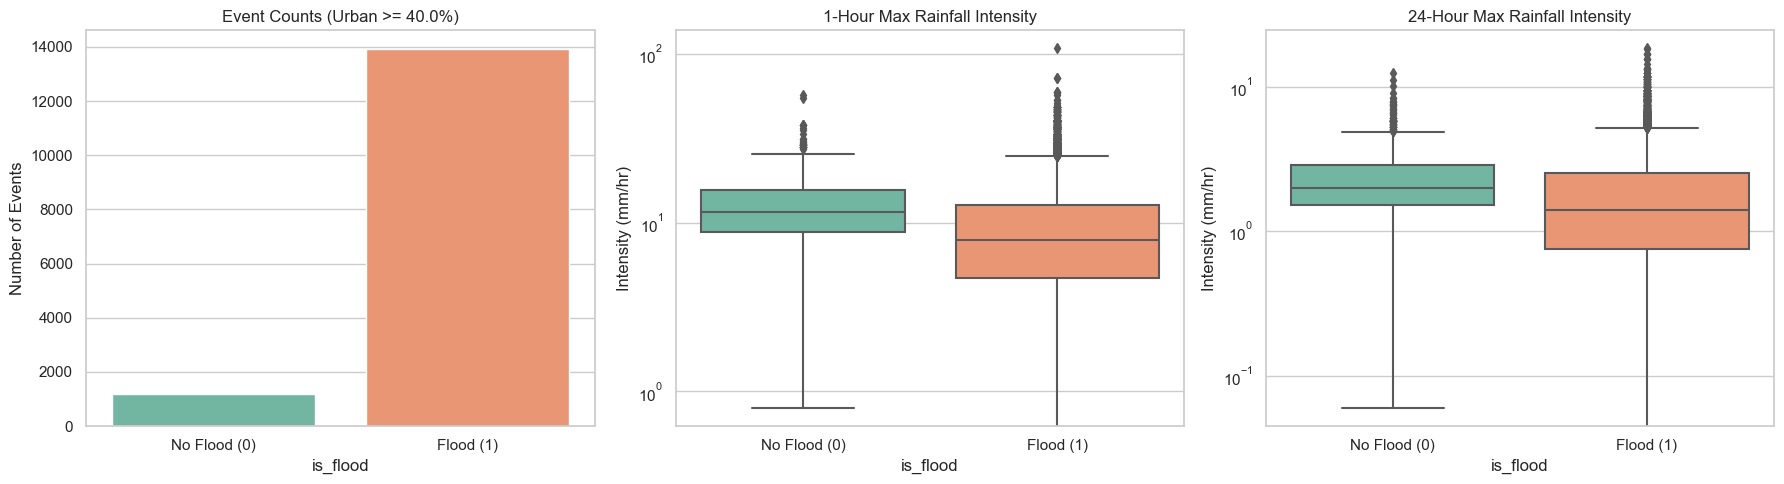

In [14]:
# =================================================================
# Urban Flood EDA (Focusing on >= 20% Urban Area)
# =================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the threshold for urban area (Assuming the column is scaled 0-100)
# If your column is scaled 0-1, change this to 0.20
URBAN_THRESHOLD = 40.0 

# Load the unified dataset
DATASET_PATH = r"D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_V01.pkl"
try:
    df = pd.read_pickle(DATASET_PATH)
except FileNotFoundError:
    print(f"File not found: {DATASET_PATH}. Please ensure it was created successfully.")
    df = pd.DataFrame() # Create empty to avoid crashing below if not found

if not df.empty:
    # 1. Filter the dataset for strictly urban basins
    urban_df = df[df['urban_percentage'] >= URBAN_THRESHOLD]
    
    print(f"Total events in dataset: {len(df)}")
    print(f"Total events after filtering (>= {URBAN_THRESHOLD}% urban): {len(urban_df)}\n")
    
    # 2. Compare class distribution
    class_counts = urban_df['is_flood'].value_counts().sort_index()
    print("--- Event Counts (Urban Basins Only) ---")
    print(f"No Flood (Class 0): {class_counts.get(0, 0)}")
    print(f"Flood (Class 1):    {class_counts.get(1, 0)}\n")
    
    # 3. Summary Statistics for key features
    features_to_compare = [
        '60_max_rainfall_intens', 
        '1440_max_rainfall_intens', 
        'PFDI_max', 
        'upa_max'
    ]
    
    cols_to_use = [c for c in features_to_compare if c in urban_df.columns]
    
    print(f"--- Mean Values by Class (Urban >= {URBAN_THRESHOLD}%) ---")
    summary_stats = urban_df.groupby('is_flood')[cols_to_use].mean().round(2)
    print(summary_stats)
    
    # 4. Visualizations
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot A: Class Counts
    sns.countplot(data=urban_df, x='is_flood', ax=axes[0], palette="Set2")
    axes[0].set_title(f'Event Counts (Urban >= {URBAN_THRESHOLD}%)')
    axes[0].set_ylabel('Number of Events')
    axes[0].set_xticklabels(['No Flood (0)', 'Flood (1)'])
    
    # Plot B: 1-Hour Rainfall Comparison
    if '60_max_rainfall_intens' in urban_df.columns:
        sns.boxplot(data=urban_df, x='is_flood', y='60_max_rainfall_intens', ax=axes[1], palette="Set2")
        axes[1].set_title('1-Hour Max Rainfall Intensity')
        axes[1].set_ylabel('Intensity (mm/hr)')
        axes[1].set_yscale('log')
        axes[1].set_xticklabels(['No Flood (0)', 'Flood (1)'])
    
    # Plot C: 24-Hour Rainfall Comparison
    if '1440_max_rainfall_intens' in urban_df.columns:
        sns.boxplot(data=urban_df, x='is_flood', y='1440_max_rainfall_intens', ax=axes[2], palette="Set2")
        axes[2].set_title('24-Hour Max Rainfall Intensity')
        axes[2].set_ylabel('Intensity (mm/hr)')
        axes[2].set_yscale('log')
        axes[2].set_xticklabels(['No Flood (0)', 'Flood (1)'])
    
    plt.tight_layout()
    plt.show()

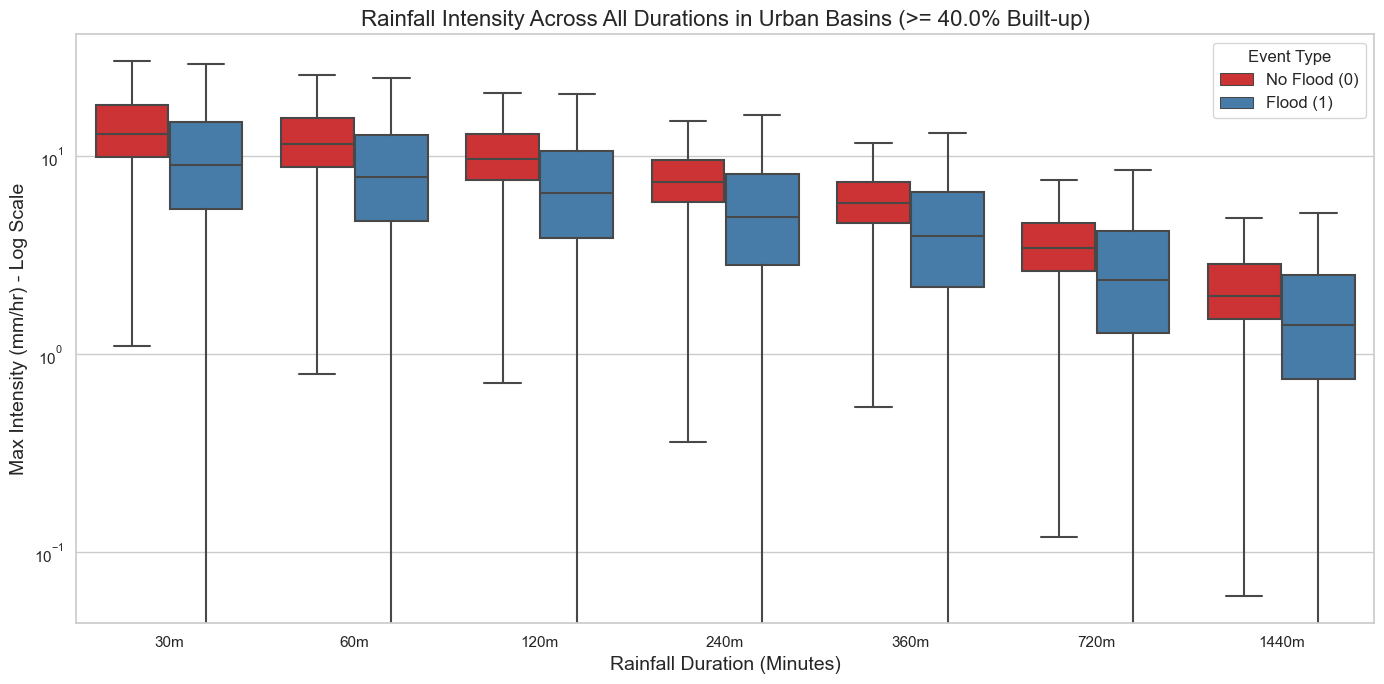

In [15]:
# =================================================================
# Urban Flood EDA: Intensity-Duration Comparison in One Figure
# =================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
URBAN_THRESHOLD = 40.0 
DATASET_PATH = r"D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_V01.pkl"

# 1. Load data
try:
    df = pd.read_pickle(DATASET_PATH)
except FileNotFoundError:
    print(f"File not found: {DATASET_PATH}")
    df = pd.DataFrame()

if not df.empty:
    # 2. Filter for urban basins only
    urban_df = df[df['urban_percentage'] >= URBAN_THRESHOLD].copy()
    
    # 3. Define the exact rainfall intensity columns in temporal order
    intensity_cols = [
        '30_max_rainfall_intens', 
        '60_max_rainfall_intens', 
        '120_max_rainfall_intens', 
        '240_max_rainfall_intens', 
        '360_max_rainfall_intens', 
        '720_max_rainfall_intens', 
        '1440_max_rainfall_intens'
    ]
    
    # Filter out columns that might be missing just in case
    intensity_cols = [col for col in intensity_cols if col in urban_df.columns]
    
    # 4. Melt the dataframe to 'long' format for seaborn
    # This transforms the columns into rows, categorizing by Duration
    melted_df = pd.melt(
        urban_df, 
        id_vars=['is_flood'], 
        value_vars=intensity_cols,
        var_name='Duration', 
        value_name='Intensity (mm/hr)'
    )
    
    # Clean up the 'Duration' labels for a cleaner X-axis (e.g., '30_max_rainfall_intens' -> '30m')
    melted_df['Duration'] = melted_df['Duration'].apply(lambda x: x.split('_')[0] + 'm')
    
    # 5. Plotting
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    
    # Create a grouped boxplot
    # We use log scale later, so we hide extreme fliers to keep the boxes readable
    ax = sns.boxplot(
        data=melted_df, 
        x='Duration', 
        y='Intensity (mm/hr)', 
        hue='is_flood', 
        palette="Set1",
        showfliers=False 
    )
    
    plt.title(f'Rainfall Intensity Across All Durations in Urban Basins (>= {URBAN_THRESHOLD}% Built-up)', fontsize=16)
    plt.xlabel('Rainfall Duration (Minutes)', fontsize=14)
    plt.ylabel('Max Intensity (mm/hr) - Log Scale', fontsize=14)
    
    # Use logarithmic scale to properly visualize both short high-intensity and long low-intensity events
    plt.yscale('log')
    
    # Clean up the legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['No Flood (0)', 'Flood (1)'], title='Event Type', fontsize=12, title_fontsize=12)
    
    plt.tight_layout()
    plt.show()

Original dataset size: 412401
Size after urban & rainfall thresholds: 48627

Class distribution after filtering:
  No Flood (0): 2984
  Flood (1):    45643



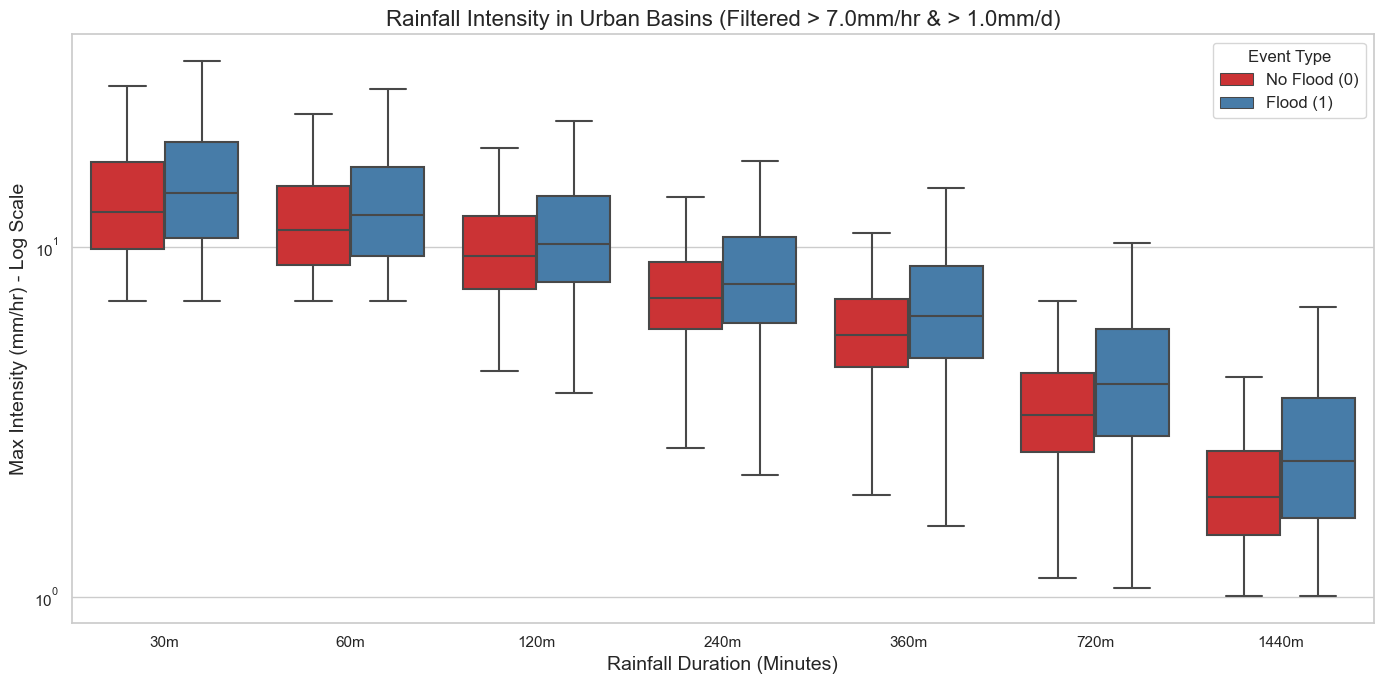

In [16]:
# =================================================================
# Urban Flood EDA: Threshold-Filtered Intensity-Duration Comparison
# =================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration thresholds
URBAN_THRESHOLD = 20.0 
THRESH_1H = 7.0
THRESH_24H = 1.0
DATASET_PATH = r"D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_V01.pkl"

# 1. Load data
try:
    df = pd.read_pickle(DATASET_PATH)
except FileNotFoundError:
    print(f"File not found: {DATASET_PATH}")
    df = pd.DataFrame()

if not df.empty:
    # 2. Filter for urban basins AND minimum rainfall thresholds
    # We apply the threshold to the entire dataset to ensure a fair comparison
    filtered_df = df[
        (df['urban_percentage'] >= URBAN_THRESHOLD) &
        (df['60_max_rainfall_intens'] > THRESH_1H) &
        (df['1440_max_rainfall_intens'] > THRESH_24H)
    ].copy()
    
    # Print the before and after statistics
    print(f"Original dataset size: {len(df)}")
    print(f"Size after urban & rainfall thresholds: {len(filtered_df)}\n")
    print("Class distribution after filtering:")
    class_counts = filtered_df['is_flood'].value_counts().sort_index()
    print(f"  No Flood (0): {class_counts.get(0, 0)}")
    print(f"  Flood (1):    {class_counts.get(1, 0)}\n")
    
    # 3. Define intensity columns
    intensity_cols = [
        '30_max_rainfall_intens', 
        '60_max_rainfall_intens', 
        '120_max_rainfall_intens', 
        '240_max_rainfall_intens', 
        '360_max_rainfall_intens', 
        '720_max_rainfall_intens', 
        '1440_max_rainfall_intens'
    ]
    
    intensity_cols = [col for col in intensity_cols if col in filtered_df.columns]
    
    # 4. Melt dataframe for plotting
    melted_df = pd.melt(
        filtered_df, 
        id_vars=['is_flood'], 
        value_vars=intensity_cols,
        var_name='Duration', 
        value_name='Intensity (mm/hr)'
    )
    
    # Clean up the labels
    melted_df['Duration'] = melted_df['Duration'].apply(lambda x: x.split('_')[0] + 'm')
    
    # 5. Plotting
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    
    ax = sns.boxplot(
        data=melted_df, 
        x='Duration', 
        y='Intensity (mm/hr)', 
        hue='is_flood', 
        palette="Set1",
        showfliers=False 
    )
    
    plt.title(f'Rainfall Intensity in Urban Basins (Filtered > {THRESH_1H}mm/hr & > {THRESH_24H}mm/d)', fontsize=16)
    plt.xlabel('Rainfall Duration (Minutes)', fontsize=14)
    plt.ylabel('Max Intensity (mm/hr) - Log Scale', fontsize=14)
    plt.yscale('log')
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['No Flood (0)', 'Flood (1)'], title='Event Type', fontsize=12, title_fontsize=12)
    
    plt.tight_layout()
    plt.show()